# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from math import factorial
import math as mt
from scipy import stats as st
import numpy as np
import seaborn as sns

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
games = pd.read_csv('/datasets/games.csv')

In [3]:
print(games.info())
print(games.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                                       Name Platform  Year_of_Release  \
14900                      My Ballet Studio      Wii           2009.0   
16150  Samurai Shodown Anthology (JP sales)      PS2           2008.0   
8261     Disney's

In [4]:
total_duplicates = games.duplicated().sum()
print(total_duplicates)

0


### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

### Analysis
The total number of records in the dataset is 16,715. There are 6 float data types and 5 object data types. The dataset also contains a large number of missing values in various columns. The user_score column is an object data type, though it should be a float, likely because of tbd values.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
games.columns = games.columns.str.lower()

In [6]:
print(games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


### 2.2 Data Type Conversion

In [7]:
print(games.dtypes)

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [8]:
games['year_of_release'] = pd.to_numeric(
    games['year_of_release'], errors='coerce').astype('Int64')

### Analysis
I changed the year_of_release column to an integer data type and leaving the missing values.

In [9]:
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')
print(games.dtypes)
games['user_score'] = games['user_score'] * 10
print(games)

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
dtype: object
                                name platform  year_of_release         genre  \
0                         Wii Sports      Wii             2006        Sports   
1                  Super Mario Bros.      NES             1985      Platform   
2                     Mario Kart Wii      Wii             2008        Racing   
3                  Wii Sports Resort      Wii             2009        Sports   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360    

### Analysis
I replaced the tbd values with NaN so the user_score column could be converted to a float data type without introducing artificial values, and I multiplied user_score by 10 to match the scale of critic_score.

### 2.3 Handling Missing Values

In [10]:
games_null = games.isnull().sum()
print(games_null)

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


In [11]:
missing_percentages = (games.isnull().sum() / len(games)) * 100
print(missing_percentages[missing_percentages > 0])

name                0.011965
year_of_release     1.609333
genre               0.011965
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64


In [12]:
game_mis = games[games['critic_score'].isnull()]
print(game_mis)

                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

In [68]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
games = games.dropna(subset=['name', 'genre'], how='any')
games_name_null = games[games['name'].isnull()]
games_genre_null = games[games['genre'].isnull()]

games['rating'] = games['rating'].fillna('unknown')

print(games_name_null)
print(games_genre_null)
print(games['rating'])

Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating, total_sales]
Index: []
Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating, total_sales]
Index: []
0              E
1        unknown
2              E
3              E
4        unknown
          ...   
16710    unknown
16711    unknown
16712    unknown
16713    unknown
16714    unknown
Name: rating, Length: 16713, dtype: object


### Analysis
I chose to leave the missing values in the critic_score and user_score columns in order to preserve the data for later calculations, the rating column I replaced missing values with unknown to get a better look at all the data. Using the mean or median to fill the NaN values could artificially skew the dataset during calculations and potentially lead to false conclusions. Since the name and genre columns only have two missing values in the same rows I decided to drop them from the data because the year of release was also much before the relevant time for this analysis. The year_of_release column was changed to an integer data type and leaving the missing values for later calculations. The missing values in the user_score, critic_score, and rating columns could be due to older releases not having an official scoring yet or newer games that haven't received scoring yet.

In [14]:
genre_total = games['genre'].value_counts()
genre_missing = games[games['critic_score'].isnull()]['genre'].value_counts()

genre_missing_pct = (genre_missing / genre_total *
                     100).fillna(0).sort_values(ascending=False)
print("Percentage of games missing critic scores by genre:")
print(genre_missing_pct)

platform_total = games['platform'].value_counts()
platform_missing = games[games['critic_score'].isnull()
                         ]['platform'].value_counts()

platform_missing_pct = (platform_missing / platform_total *
                        100).fillna(0).sort_values(ascending=False)
print("Percentage of games missing critic scores by platform:")
print(platform_missing_pct)

Percentage of games missing critic scores by genre:
Adventure       75.211051
Misc            70.114286
Puzzle          61.379310
Simulation      59.679267
Strategy        55.783309
Fighting        51.825677
Role-Playing    50.801068
Sports          49.148211
Platform        44.031532
Action          43.900267
Racing          40.592474
Shooter         28.647014
Name: genre, dtype: float64
Percentage of games missing critic scores by platform:
2600    100.000000
PCFX    100.000000
WS      100.000000
TG16    100.000000
SNES    100.000000
GB      100.000000
SCD     100.000000
SAT     100.000000
GEN     100.000000
GG      100.000000
N64     100.000000
NES     100.000000
NG      100.000000
3DO     100.000000
PS       83.291562
DC       73.076923
PSV      72.093023
3DS      67.692308
DS       66.666667
PSP      61.786600
Wii      55.681818
GBA      46.715328
PS2      39.935215
WiiU     38.775510
PS3      38.392186
PS4      35.714286
XOne     31.578947
X360     27.416799
PC       26.591376
GC

### Analysis
The critic_score column may contain missing values because some mobile games do not receive expert reviews, and older platforms may not have had as much expert review coverage.

### 2.4 Calculate Total Sales

In [15]:
games['total_sales'] = games['na_sales'] + \
    games['eu_sales'] + games['jp_sales'] + games['other_sales']
print(games.sample(5))

                                         name platform  year_of_release  \
16004                   Brave: The Video Game       DS             2012   
12873            Minna to Kimi no Piramekino!       DS             2010   
16250                          Theatre Of War       PC             2007   
6901   Midway Arcade Treasures: Extended Play      PSP             2005   
13285                              Rugby 2005       XB             2005   

          genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
16004    Action      0.00      0.01      0.00         0.00           NaN   
12873      Misc      0.00      0.00      0.05         0.00           NaN   
16250  Strategy      0.00      0.01      0.00         0.00          66.0   
6901       Misc      0.21      0.00      0.00         0.02          63.0   
13285    Sports      0.04      0.01      0.00         0.00          75.0   

       user_score rating  total_sales  
16004         NaN   E10+         0.01  
12873       

# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [16]:
games_year = games['year_of_release'].value_counts().sort_index()
print(games_year)

1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64


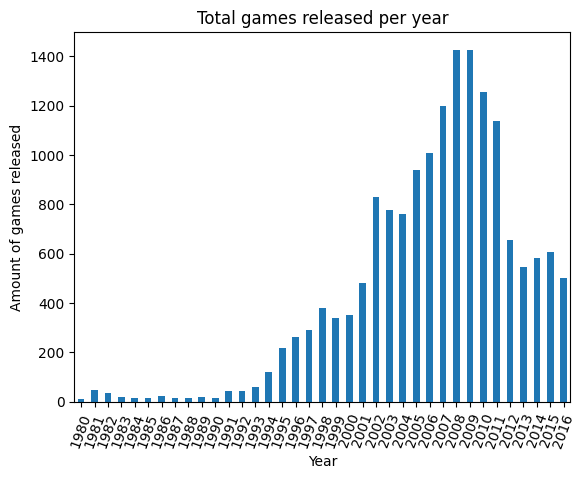

In [17]:
games_year.plot(kind='bar', xlabel='Year', ylabel='Amount of games released',
                title='Total games released per year', rot=70)
plt.show()

In [18]:
print(games_year.describe())

count      37.000000
mean      444.432432
std       451.604334
min         9.000000
25%        36.000000
50%       338.000000
75%       762.000000
max      1427.000000
Name: year_of_release, dtype: float64


### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

### Analysis
The highest number of game releases occurred between 2005 and 2010, with peaks in 2008 and 2009. Earlier years in the dataset had fewer game releases than later years. Although the number of releases declined after 2010, there is still a significant amount of recent data available to support predictions.

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [19]:
platform_sales = games.groupby(['platform', 'year_of_release'])[
    'total_sales'].sum()
print(platform_sales)

platform  year_of_release
2600      1980               11.38
          1981               35.68
          1982               28.88
          1983                5.84
          1984                0.27
                             ...  
XB        2008                0.18
XOne      2013               18.96
          2014               54.07
          2015               60.14
          2016               26.15
Name: total_sales, Length: 238, dtype: float64


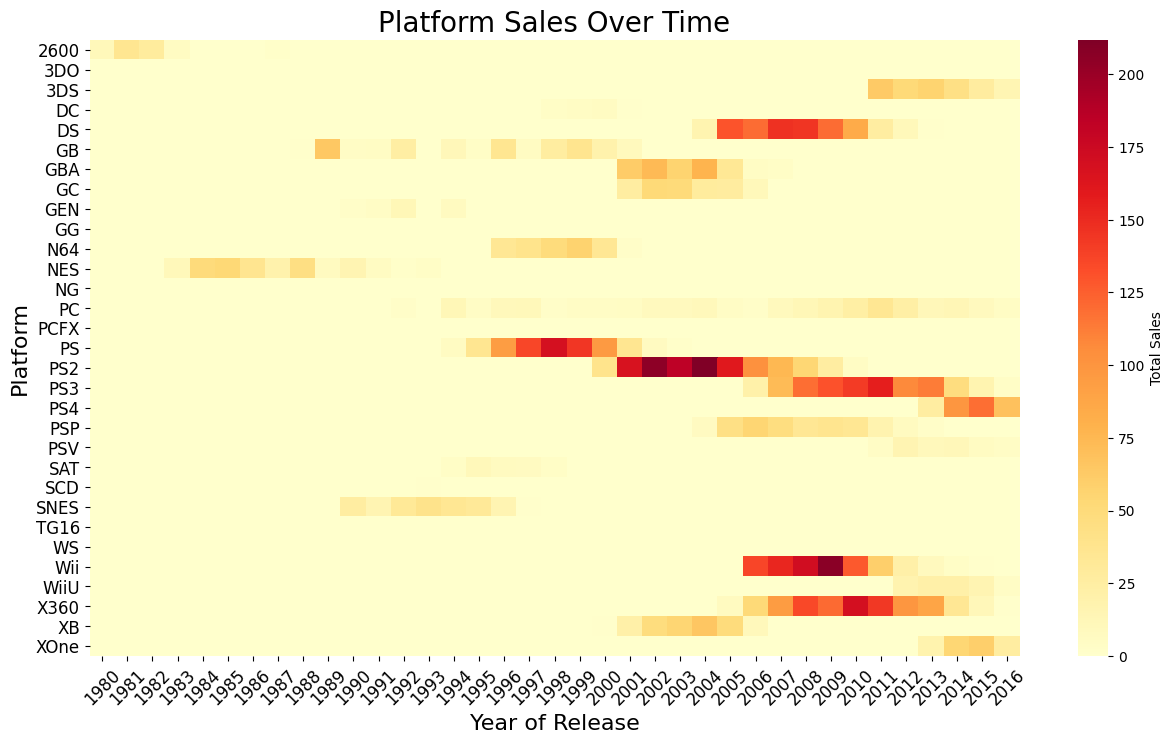

In [20]:
platform_sales_pivot = games.pivot_table(
    values='total_sales',
    index='platform',
    columns='year_of_release',
    aggfunc='sum',
    fill_value=0
)


plt.figure(figsize=(15, 8))
sns.heatmap(platform_sales_pivot, cmap='YlOrRd',
            cbar_kws={'label': 'Total Sales'})
plt.title('Platform Sales Over Time', fontsize=20)
plt.xlabel('Year of Release', fontsize=16)
plt.ylabel('Platform', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [21]:
peak_sales = platform_sales_pivot.max(axis=1)
recent_avg = platform_sales_pivot.loc[:, 2012:2016].mean(axis=1)
decline_ratio = recent_avg / peak_sales
print(decline_ratio)

platform
2600    0.000000
3DO     0.000000
3DS     0.615854
DC      0.000000
DS      0.017082
GB      0.000000
GBA     0.000000
GC      0.000000
GEN     0.000000
GG      0.000000
N64     0.000000
NES     0.000000
NG      0.000000
PC      0.357693
PCFX    0.000000
PS      0.000000
PS2     0.000000
PS3     0.368402
PS4     0.528410
PSP     0.040456
PSV     0.607536
SAT     0.000000
SCD     0.000000
SNES    0.000000
TG16    0.000000
WS      0.000000
Wii     0.034179
WiiU    0.746164
X360    0.278233
XB      0.000000
XOne    0.529830
dtype: float64


### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

### Analysis
To analyze which platforms were still relevant for 2017 campaigns, I used a decline ratio that compares each platform’s average sales from 2012 to 2016 with its peak sales. The closer the decline ratio is to 1, the closer the platform’s recent performance is to its historical peak, suggesting that it remains relatively strong and relevant for 2017 campaigns. Based on this measure, WiiU, XOne, PS4, 3DS, and PSV showed the most consistent sales over time, while platforms with ratios at or near 0, such as PS2, DS, Wii, GBA, and NES, appear to have disappeared from the market. Overall, the typical lifecycle of a gaming platform seems to include growth, a peak sales period, and then decline as newer platforms replace older ones.

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [22]:
relevant_years = [2012, 2013, 2014, 2015, 2016]
games_relevant = games[games['year_of_release'].isin(relevant_years)]

### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

### Analysis
I selected the years 2012 through 2016 for analysis because most older gaming platforms are not relevant for 2017 campaigns. The current market is more likely to release new games on newer platforms due to technological advancements. The heatmap also shows that most platforms have a lifespan of less than ten years, with peak performance occurring around five years or earlier.

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [23]:
print(games_relevant)

                                name platform  year_of_release         genre  \
16                Grand Theft Auto V      PS3             2013        Action   
23                Grand Theft Auto V     X360             2013        Action   
31         Call of Duty: Black Ops 3      PS4             2015       Shooter   
33               Pokemon X/Pokemon Y      3DS             2013  Role-Playing   
34        Call of Duty: Black Ops II      PS3             2012       Shooter   
...                              ...      ...              ...           ...   
16703               Strawberry Nauts      PSV             2016     Adventure   
16707               Aiyoku no Eustia      PSV             2014          Misc   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

In [24]:
platform_sales_rel = games_relevant.groupby(
    'platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales_rel)

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64


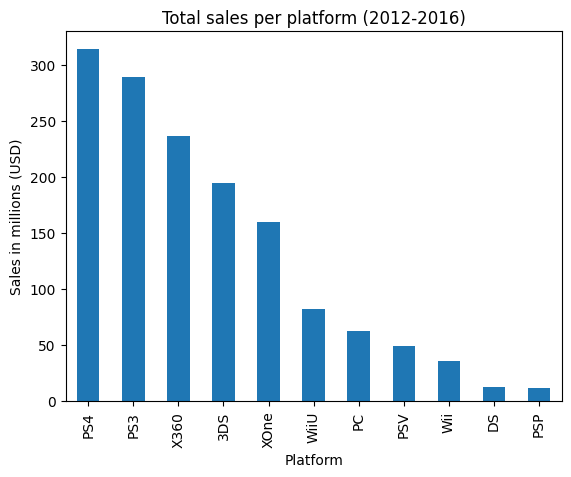

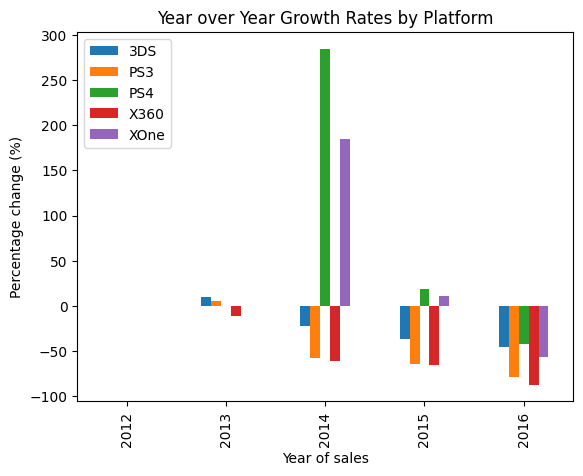

In [25]:
platform_sales_rel.plot(kind='bar', xlabel='Platform',
                        ylabel='Sales in millions (USD)', title='Total sales per platform (2012-2016)')
plt.show()


selected_platforms = ['PS4', 'PS3', 'X360', '3DS', 'XOne']

games_selected = games_relevant[games_relevant['platform'].isin(
    selected_platforms)]

platform_year_sales = games_selected.groupby(
    ['platform', 'year_of_release'])['total_sales'].sum()
platform_year_df = platform_year_sales.reset_index()
platform_year_df = platform_year_df.pivot(
    index='year_of_release', columns='platform', values='total_sales')

growth_rates = platform_year_df.pct_change() * 100

growth_rates.plot(kind='bar', title='Year over Year Growth Rates by Platform',
                  xlabel='Year of sales', ylabel='Percentage change (%)')
plt.legend(loc='upper left')
plt.show()

### Analysis
The platform with the highest total sales between 2012 and 2016 was the PS4, followed by the PS3. The X360, 3DS, and XOne followed in that order. The 3DS showed consistently declining sales throughout the period. The PS3 experienced a sharp drop in total sales after the release of the PS4, and its sales continued to decline afterward. PS4 sales also appear to be decreasing, although the 2016 data may be incomplete. The X360 and XOne showed sales patterns similar to those of the PS3 and PS4.

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

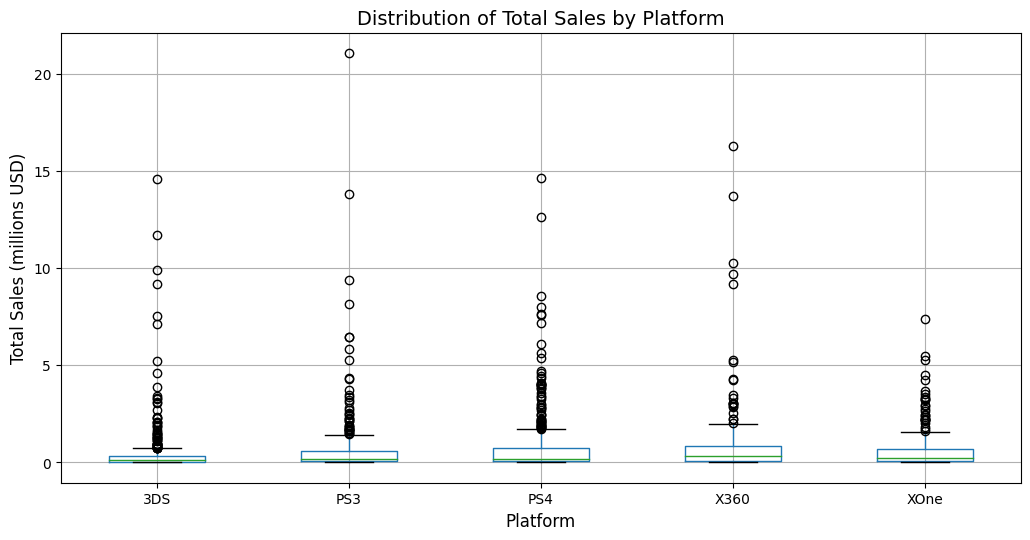

In [26]:
games_selected.boxplot(column='total_sales', by='platform', figsize=(12, 6))
plt.title('Distribution of Total Sales by Platform', fontsize=14)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Total Sales (millions USD)', fontsize=12)
plt.suptitle('')
plt.show()

In [27]:
average_sales = games_selected.groupby('platform')['total_sales'].mean()
print(average_sales.sort_values(ascending=False))

platform
X360    0.810068
PS4     0.801378
XOne    0.645020
PS3     0.585781
3DS     0.491439
Name: total_sales, dtype: float64


### Analysis
The box plot shows that sales for the 3DS are noticeably lower than for the other platforms, while PS3, PS4, XOne, and X360 are relatively close overall. Among these platforms, the X360 has the highest average and median global sales, making it the strongest platform in terms of typical game sales. The XOne has a higher median than both the PS3 and PS4, although the PS4 has a higher average sales value, which suggests that some stronger selling PS4 games pull its average upward. The PS4 also shows the greatest number of outliers, followed by the 3DS and PS3, indicating that these platforms had more unusually high selling games. Overall, average sales by platform rank from highest to lowest as X360, PS4, XOne, PS3, and 3DS.

## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [28]:
x360_sales = games_selected[games_selected['platform'] == 'X360']
print(x360_sales)

                             name platform  year_of_release     genre  \
23             Grand Theft Auto V     X360             2013    Action   
35     Call of Duty: Black Ops II     X360             2012   Shooter   
60           Call of Duty: Ghosts     X360             2013   Shooter   
66                         Halo 4     X360             2012   Shooter   
72                      Minecraft     X360             2013      Misc   
...                           ...      ...              ...       ...   
16450    Turbo: Super Stunt Squad     X360             2013    Sports   
16460       Young Justice: Legacy     X360             2013    Action   
16491                        Ride     X360             2015    Racing   
16613    Dragon Ball Z for Kinect     X360             2012  Fighting   
16654          Ben 10 Omniverse 2     X360             2013    Action   

       na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
23         9.66      5.14      0.06         1

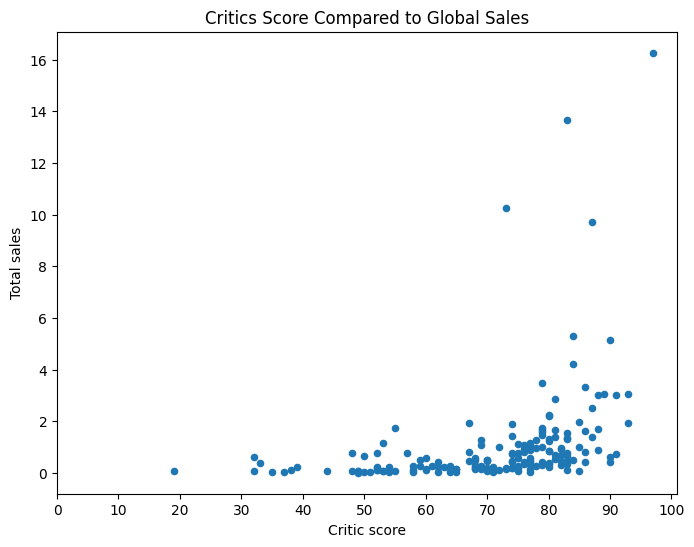

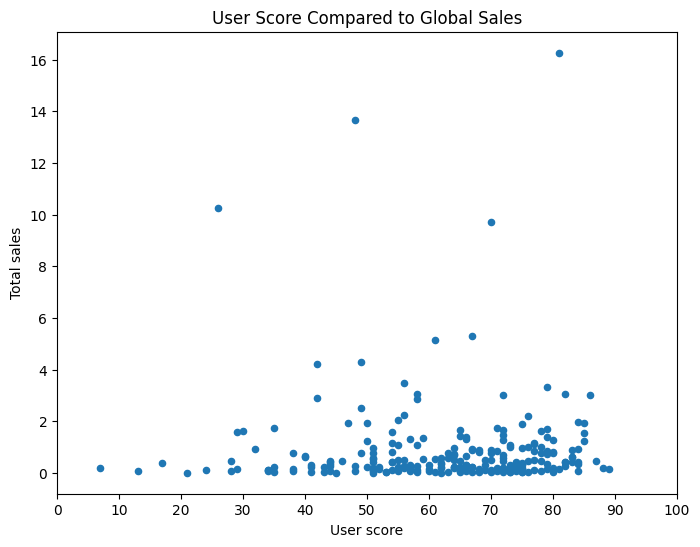

In [29]:
ax = x360_sales.plot(kind='scatter', x='critic_score', y='total_sales', xlabel='Critic score',
                     ylabel='Total sales', title='Critics Score Compared to Global Sales', figsize=(8, 6))
ax.set_xticks(range(0, 101, 10))
ax1 = x360_sales.plot(kind='scatter', x='user_score', y='total_sales', xlabel='User score',
                      ylabel='Total sales', title='User Score Compared to Global Sales', figsize=(8, 6))
ax1.set_xticks(range(0, 101, 10))
plt.show()

In [30]:
critic_correlation = x360_sales['critic_score'].corr(x360_sales['total_sales'])


user_correlation = x360_sales['user_score'].corr(x360_sales['total_sales'])

print(
    f"Correlation between critic scores and total sales: {critic_correlation:.3f}")
print(
    f"Correlation between user scores and total sales: {user_correlation:.3f}")

Correlation between critic scores and total sales: 0.361
Correlation between user scores and total sales: 0.006


### Analysis
The correlation values show that critic scores have a much stronger relationship with total sales than user scores for Xbox 360 games. The correlation between critic_score and total_sales is 0.361, which indicates a moderate positive relationship, while the correlation between user_score and total_sales is 0.006, which indicates an extremely weak relationship with almost no predictive value. This matches the scatter plots, where games with higher critic scores generally show higher total sales, while the user score scatter plot shows little to no clear upward pattern as scores increase. Overall, this suggests that critic reviews are more useful than user reviews when trying to predict the success of games released on the Xbox 360.

## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [31]:
multi_platform_games = games_selected.groupby(
    ['name', 'year_of_release'])['platform'].nunique()
multi_platform_games = multi_platform_games[multi_platform_games > 1].reset_index(
)
print(multi_platform_games)

                                                  name  year_of_release  \
0                           2014 FIFA World Cup Brazil             2014   
1                                        7 Days to Die             2016   
2    Adventure Time: Explore the Dungeon Because I ...             2013   
3           Adventure Time: Finn & Jake Investigations             2015   
4          Adventure Time: The Secret of the Nameless              2014   
..                                                 ...              ...   
449                                             ZombiU             2016   
450                                Zombie Army Trilogy             2015   
451                   Zone of the Enders HD Collection             2012   
452                                  Zoo Tycoon (2013)             2013   
453                                      [Prototype 2]             2012   

     platform  
0           2  
1           2  
2           3  
3           5  
4           2  
.. 

platform                                                             3DS  \
name                                               year_of_release         
2014 FIFA World Cup Brazil                         2014              NaN   
7 Days to Die                                      2016              NaN   
Adventure Time: Explore the Dungeon Because I D... 2013             0.14   
Adventure Time: Finn & Jake Investigations         2015             0.09   
Adventure Time: The Secret of the Nameless         2014             0.01   
...                                                                  ...   
ZombiU                                             2016              NaN   
Zombie Army Trilogy                                2015              NaN   
Zone of the Enders HD Collection                   2012              NaN   
Zoo Tycoon (2013)                                  2013              NaN   
[Prototype 2]                                      2012              NaN   

platform   

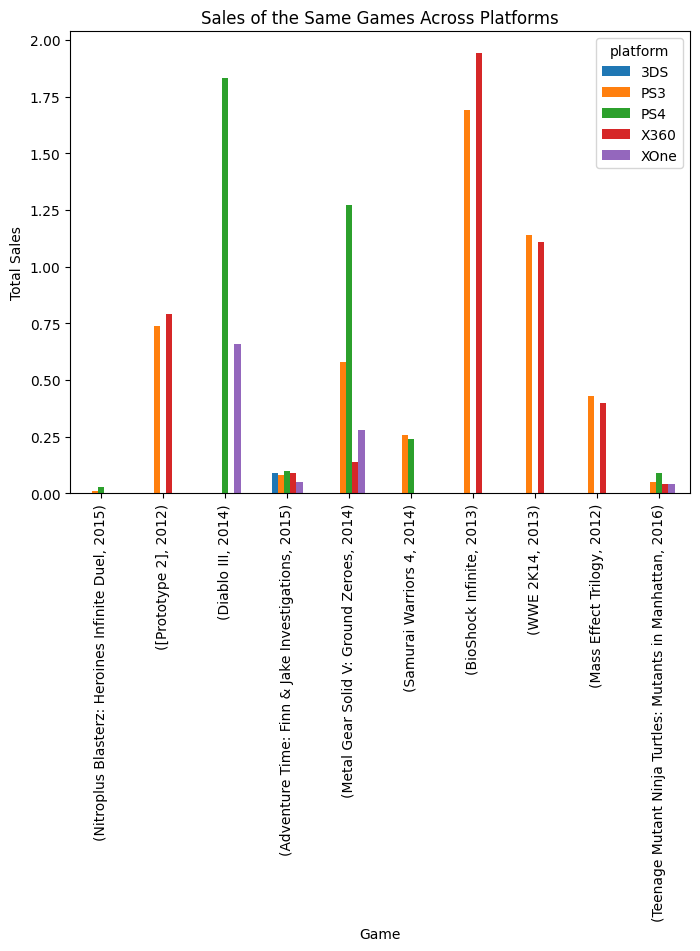

In [32]:
multi_platform_df = games_selected.merge(
    multi_platform_games[['name', 'year_of_release']],
    on=['name', 'year_of_release'],
    how='inner'
)

sales_comparison = multi_platform_df.pivot_table(
    index=['name', 'year_of_release'],
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

print(sales_comparison)

sales_comparison.sample(10).plot(kind='bar', figsize=(
    8, 6), title='Sales of the Same Games Across Platforms', xlabel='Game', ylabel='Total Sales')
plt.show()

### Analysis
I filtered the data to include only the top-selling platforms and the relevant years so I could compare the total sales of the same games released across those platforms. Most games were released on two different platforms, while a smaller number were released on all five. The comparison shows that when the same game is released on both PS4 and XOne, the PS4 usually generates higher total sales than the XOne. Similarly, when the same game is released on both PS3 and X360, the PS3 most often has higher total sales. There were fewer games released on the 3DS alongside the other platforms, but when that did happen, the 3DS generally remained competitive, although its total sales were usually slightly lower than those of the other platforms.

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [33]:
print(games_relevant)

                                name platform  year_of_release         genre  \
16                Grand Theft Auto V      PS3             2013        Action   
23                Grand Theft Auto V     X360             2013        Action   
31         Call of Duty: Black Ops 3      PS4             2015       Shooter   
33               Pokemon X/Pokemon Y      3DS             2013  Role-Playing   
34        Call of Duty: Black Ops II      PS3             2012       Shooter   
...                              ...      ...              ...           ...   
16703               Strawberry Nauts      PSV             2016     Adventure   
16707               Aiyoku no Eustia      PSV             2014          Misc   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

In [34]:
genre_sales = games_relevant.groupby(
    'genre')['total_sales'].sum().sort_values(ascending=False)
print(genre_sales)

genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64


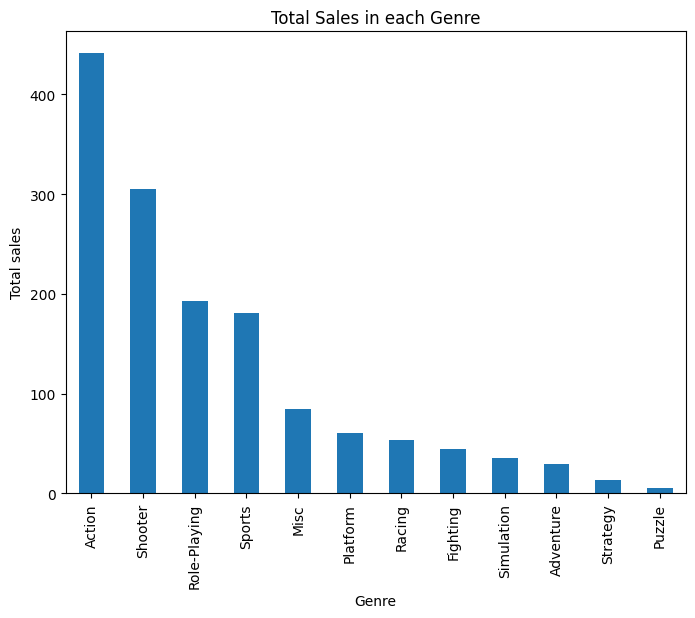

In [35]:
genre_sales.plot(kind='bar', figsize=(
    8, 6), title='Total Sales in each Genre', ylabel='Total sales', xlabel='Genre')
plt.show()

genre
Action          30.495047
Shooter         21.066276
Role-Playing    13.328448
Sports          12.517542
Misc             5.878896
Platform         4.216988
Racing           3.698506
Fighting         3.075636
Simulation       2.427879
Adventure        2.034524
Strategy         0.922207
Puzzle           0.338050
Name: total_sales, dtype: float64


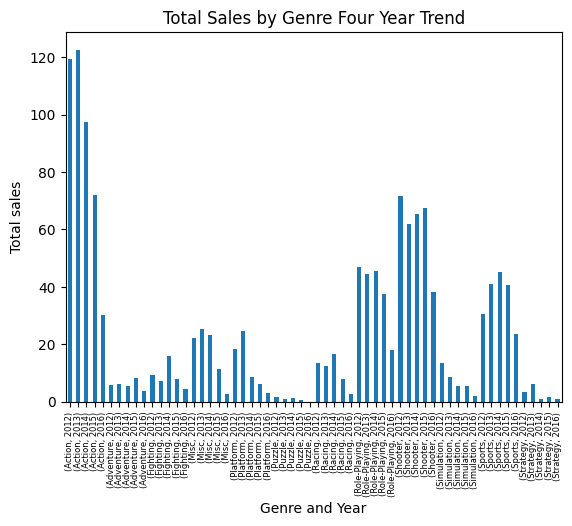

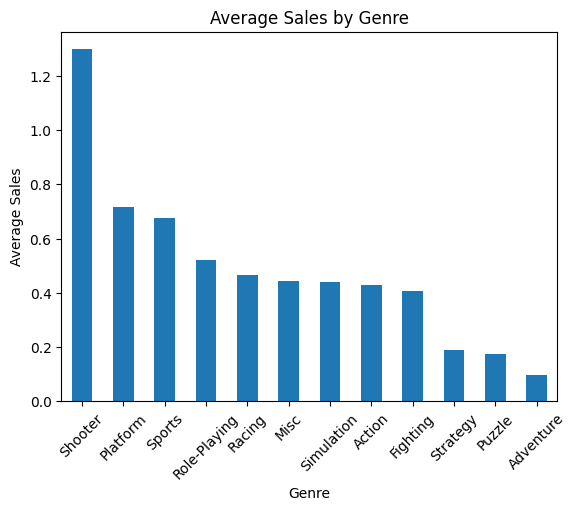

In [36]:
total_market = games_relevant['total_sales'].sum()
market_share = (genre_sales / total_market) * 100
print(market_share)

genre_year_sales = games_relevant.groupby(['genre', 'year_of_release'])[
    'total_sales'].sum().sort_index()
genre_year_sales.plot(kind='bar', xlabel='Genre and Year',
                      ylabel='Total sales', title='Total Sales by Genre Four Year Trend')
plt.xticks(fontsize=6)
plt.show()

average_genre_sales = games_relevant.groupby(
    'genre')['total_sales'].mean().sort_values(ascending=False)


average_genre_sales.plot(kind='bar', xlabel='Genre',
                         ylabel='Average Sales', title='Average Sales by Genre')
plt.xticks(rotation=45)
plt.show()

### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

### Analysis
The general distribution of games by genre shows that Action, Shooter, and Role-Playing are the most profitable genres overall, ranking first, second, and third in total sales. Action leads by a wide margin with more than 441 million in total sales and accounts for about 30.5 percent of the market, while the top three genres together make up roughly 65 percent of total market share. At the other end, Strategy and Puzzle are the lowest-performing genres in terms of total sales. Looking at recent trends, the Action and Role-Playing genres show a decline in sales in the most recent years, while Shooter appears more consistent, assuming the 2016 data is incomplete. In terms of average performance, Shooter has the highest average sales per game, followed by Platform, Sports, Role-Playing, Racing, Misc, Simulation, and then Action, suggesting that although Action is dominant in total sales because of its large number of releases, Shooter tends to perform better on average.

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [58]:

platform_regional = games_relevant.groupby(
    'platform')['na_sales', 'eu_sales', 'jp_sales'].sum()
print(platform_regional)

top_5_na = games_relevant.groupby(
    'platform')['na_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 platforms in North America:")
print(top_5_na)

top_5_eu = games_relevant.groupby(
    'platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 platforms in Europe:")
print(top_5_eu)

top_5_jp = games_relevant.groupby(
    'platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 platforms in Japan:")
print(top_5_jp)

          na_sales  eu_sales  jp_sales
platform                              
3DS          55.31     42.64     87.79
DS            4.59      3.53      3.72
PC           19.12     37.76      0.00
PS3         103.38    106.86     35.29
PS4         108.74    141.09     15.96
PSP           0.13      0.42     10.47
PSV          10.98     11.36     21.04
Wii          17.45     11.92      3.39
WiiU         38.10     25.13     13.01
X360        140.05     74.52      1.57
XOne         93.12     51.59      0.34
Top 5 platforms in North America:
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

Top 5 platforms in Europe:
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

Top 5 platforms in Japan:
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


In [59]:
total_na_market = games_relevant['na_sales'].sum()
total_eu_market = games_relevant['eu_sales'].sum()
total_jp_market = games_relevant['jp_sales'].sum()

na_market_share = (top_5_na / total_na_market) * 100
eu_market_share = (top_5_eu / total_eu_market) * 100
jp_market_share = (top_5_jp / total_jp_market) * 100

print("North America Market Share (%):")
print(na_market_share)
print("\nEurope Market Share (%):")
print(eu_market_share)
print("\nJapan Market Share (%):")
print(jp_market_share)

North America Market Share (%):
platform
X360    23.698326
PS4     18.400257
PS3     17.493274
XOne    15.757145
3DS      9.359189
Name: na_sales, dtype: float64

Europe Market Share (%):
platform
PS4     27.838286
PS3     21.084409
X360    14.703445
XOne    10.179156
3DS      8.413243
Name: eu_sales, dtype: float64

Japan Market Share (%):
platform
3DS     45.586250
PS3     18.324852
PSV     10.925330
PS4      8.287465
WiiU     6.755634
Name: jp_sales, dtype: float64


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [60]:
regional_comparison = pd.concat([top_5_na, top_5_eu, top_5_jp],
                                keys=['North America', 'Europe', 'Japan'],
                                names=['Region', 'Platform'])
print(regional_comparison)

Region         Platform
North America  X360        140.05
               PS4         108.74
               PS3         103.38
               XOne         93.12
               3DS          55.31
Europe         PS4         141.09
               PS3         106.86
               X360         74.52
               XOne         51.59
               3DS          42.64
Japan          3DS          87.79
               PS3          35.29
               PSV          21.04
               PS4          15.96
               WiiU         13.01
dtype: float64


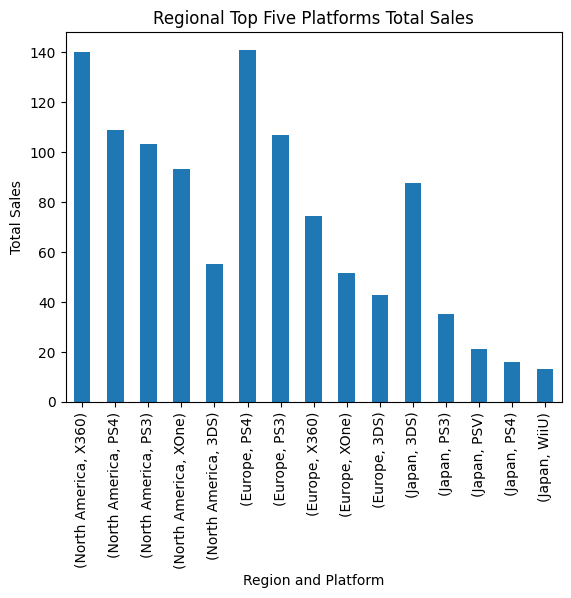

In [61]:
regional_comparison.plot(kind='bar', xlabel='Region and Platform',
                         ylabel='Total Sales', title='Regional Top Five Platforms Total Sales')

plt.show()

### Analysis
The top five platforms in North America and Europe include the same systems, but in a slightly different order, while Japan has a noticeably different top five based on total sales. In North America, the top five platforms are X360, PS4, PS3, XOne, and 3DS, while in Europe they are PS4, PS3, X360, XOne, and 3DS. In contrast, Japan’s top five platforms are 3DS, PS3, PSV, PS4, and WiiU. The leading platform in both North America and Europe holds a market share of about 25 percent of each region’s total sales, with X360 leading in North America and PS4 leading in Europe. Japan differs much more sharply, as the 3DS alone accounts for nearly 50 percent of the total market there. This is especially notable because while the 3DS is the top-selling platform in Japan, it ranks at the bottom of the top five platforms in both North America and Europe, showing that platform preferences vary significantly across regions.

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [62]:
platform_regional_genre = games_relevant.groupby(
    'genre')['na_sales', 'eu_sales', 'jp_sales'].sum()
print(platform_regional_genre)

top_5_na_genre = games_relevant.groupby(
    'genre')['na_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Genres in North America:")
print(top_5_na_genre)

top_5_eu_genre = games_relevant.groupby(
    'genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Genres in Europe:")
print(top_5_eu_genre)

top_5_jp_genre = games_relevant.groupby(
    'genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 Genres in Japan:")
print(top_5_jp_genre)

              na_sales  eu_sales  jp_sales
genre                                     
Action          177.84    159.34     52.80
Adventure         8.92      9.46      8.24
Fighting         19.79     10.79      9.44
Misc             38.19     26.32     12.86
Platform         25.38     21.41      8.63
Puzzle            1.13      1.40      2.14
Racing           17.22     27.29      2.50
Role-Playing     64.00     48.53     65.44
Shooter         144.77    113.47      9.23
Simulation        7.97     14.55     10.41
Sports           81.53     69.09      8.01
Strategy          4.23      5.17      2.88
Top 5 Genres in North America:
genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

Top 5 Genres in Europe:
genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

Top 5 Genres in Japan:
genre
Role-Pla

### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

Region         Genre       
North America  Action          177.84
               Shooter         144.77
               Sports           81.53
               Role-Playing     64.00
               Misc             38.19
Europe         Action          159.34
               Shooter         113.47
               Sports           69.09
               Role-Playing     48.53
               Racing           27.29
Japan          Role-Playing     65.44
               Action           52.80
               Misc             12.86
               Simulation       10.41
               Fighting          9.44
dtype: float64


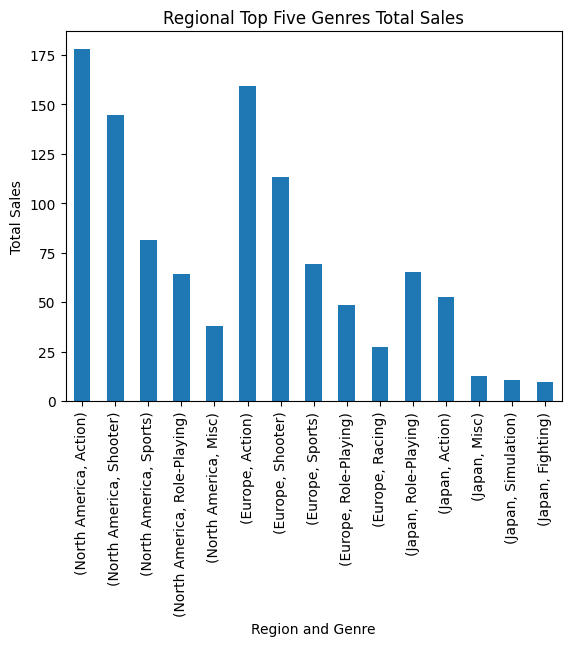

In [63]:
regional_comparison_genre = pd.concat([top_5_na_genre, top_5_eu_genre, top_5_jp_genre],
                                      keys=['North America',
                                            'Europe', 'Japan'],
                                      names=['Region', 'Genre'])
print(regional_comparison_genre)

regional_comparison_genre.plot(kind='bar', xlabel='Region and Genre',
                               ylabel='Total Sales', title='Regional Top Five Genres Total Sales')

plt.show()

### Analysis
Genre preferences do appear to differ across individual regions. In North America, Action generates the highest total sales at 177.84, followed by Shooter at 144.77, Sports at 81.53, Role-Playing at 64.00, and Misc at 38.19, showing a strong preference for action- and shooter-based games. Europe follows a very similar pattern, with Action also leading at 159.34, followed by Shooter at 113.47, Sports at 69.09, Role-Playing at 48.53, and Racing at 27.29, which suggests that North America and Europe have closely aligned genre preferences. Japan shows a different pattern, with Role-Playing leading at 65.44, followed by Action at 52.80, Misc at 12.86, Simulation at 10.41, and Fighting at 9.44. Overall, this suggests that genre preferences vary by region, with Action and Shooter performing best in North America and Europe, while Japan shows much stronger sales for Role-Playing and other genres that are less dominant in the Western regions.

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [69]:
platform_regional_rating = games_relevant.groupby(
    'rating')['na_sales', 'eu_sales', 'jp_sales'].sum()
print(platform_regional_rating)

na_rating = games_relevant.groupby(
    'rating')['na_sales'].sum().sort_values(ascending=False)
print("ESRB rating in North America:")
print(na_rating)

eu_rating = games_relevant.groupby(
    'rating')['eu_sales'].sum().sort_values(ascending=False)
print("\nESRB rating in Europe:")
print(eu_rating)

jp_rating = games_relevant.groupby(
    'rating')['jp_sales'].sum().sort_values(ascending=False)
print("\nESRB rating in Japan:")
print(jp_rating)

         na_sales  eu_sales  jp_sales
rating                               
E          114.37    113.03     28.33
E10+        75.70     55.37      8.19
M          231.57    193.96     21.20
T           66.02     52.96     26.02
Unknown    103.31     91.50    108.84
ESRB rating in North America:
rating
M          231.57
E          114.37
Unknown    103.31
E10+        75.70
T           66.02
Name: na_sales, dtype: float64

ESRB rating in Europe:
rating
M          193.96
E          113.03
Unknown     91.50
E10+        55.37
T           52.96
Name: eu_sales, dtype: float64

ESRB rating in Japan:
rating
Unknown    108.84
E           28.33
T           26.02
M           21.20
E10+         8.19
Name: jp_sales, dtype: float64


Region         Rating 
North America  M          231.57
               E          114.37
               Unknown    103.31
               E10+        75.70
               T           66.02
Europe         M          193.96
               E          113.03
               Unknown     91.50
               E10+        55.37
               T           52.96
Japan          Unknown    108.84
               E           28.33
               T           26.02
               M           21.20
               E10+         8.19
dtype: float64


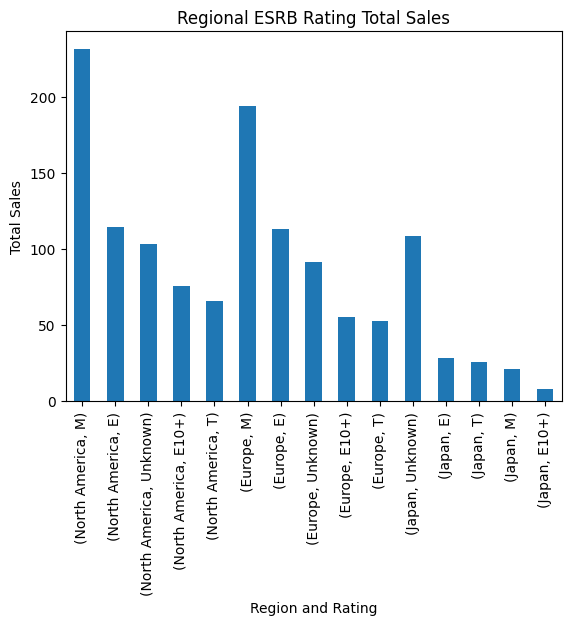

In [70]:
regional_comparison_rating = pd.concat([na_rating, eu_rating, jp_rating],
                                       keys=['North America',
                                             'Europe', 'Japan'],
                                       names=['Region', 'Rating'])
print(regional_comparison_rating)

regional_comparison_rating.plot(kind='bar', xlabel='Region and Rating',
                                ylabel='Total Sales', title='Regional ESRB Rating Total Sales')

plt.show()

### Analysis
ESRB ratings do appear to affect sales differently across individual regions, although the presence of many games with unknown ratings is also important. In North America, games rated M generate the highest total sales at 231.57, followed by E at 114.37, Unknown at 103.31, E10+ at 75.70, and T at 66.02, showing a strong preference for more mature-rated games. Europe follows a very similar pattern, with M-rated games also leading at 193.96, followed by E at 113.03, Unknown at 91.50, E10+ at 55.37, and T at 52.96, which suggests that North America and Europe have comparable rating preferences. Japan shows a different pattern, with Unknown-rated games leading by a wide margin at 108.84, followed by E at 28.33, T at 26.02, M at 21.20, and E10+ at 8.19. Overall, this suggests that ESRB ratings do influence regional sales, with mature-rated games performing best in North America and Europe, while Japan shows stronger sales for games with unknown ratings and, among officially rated games, more general-audience titles.

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [45]:
xone_user = games_relevant[games_relevant['platform']
                           == 'XOne']['user_score'].dropna()
pc_user = games_relevant[games_relevant['platform']
                         == 'PC']['user_score'].dropna()

alpha = .05

user_results_platform = st.ttest_ind(xone_user, pc_user, equal_var=False)

print('Xbox One vs PC')
print('p-value:', user_results_platform.pvalue)

if user_results_platform.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Xbox One vs PC
p-value: 0.5489537965135056
Fail to reject the null hypothesis


In [46]:
action_user = games_relevant[games_relevant['genre']
                             == 'Action']['user_score'].dropna()
sports_user = games_relevant[games_relevant['genre']
                             == 'Sports']['user_score'].dropna()

user_results_genre = st.ttest_ind(action_user, sports_user, equal_var=False)

print('\nAction vs Sports')
print('p-value:', user_results_genre.pvalue)

if user_results_genre.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')


Action vs Sports
p-value: 4.243077765726105e-20
Reject the null hypothesis


### Analysis
To test these hypotheses, I set the alpha threshold at 0.05 and used independent two-sample t-tests because each comparison involved the means of two separate and unrelated groups. For the Xbox One and PC test, the null hypothesis was that the average user ratings for Xbox One and PC are the same, and the alternative hypothesis was that the average user ratings for Xbox One and PC are different. Since the p-value was 0.5489537965135056, which is greater than 0.05, I failed to reject the null hypothesis, meaning there is not enough evidence to conclude that the average user ratings for Xbox One and PC are different. For the Action and Sports test, the null hypothesis was that the average user ratings for Action and Sports games are the same, and the alternative hypothesis was that the average user ratings for Action and Sports games are different. Since the p-value was 4.243077765726105e-20, which is far below 0.05, I rejected the null hypothesis and concluded that the average user ratings for Action and Sports games are significantly different. The criteria used for both tests were based on comparing the p-value to the alpha level, because this determines whether the observed difference in sample means is statistically significant or likely due to random variation.

# Step 6. Write a general conclusion


### Analysis
Based on the analysis, the strongest patterns for planning Ice’s 2017 advertising campaign are tied to platform relevance, genre performance, regional preferences, review influence, and rating differences. Since older platforms appear to follow a lifecycle of growth, peak, and decline, and many are no longer relevant, the most useful platforms for a 2017 campaign are PS4, XOne, WiiU, 3DS, and PSV, with PS4 standing out as especially important because it had the highest total sales from 2012 to 2016 and generally outperformed XOne when the same games were released on both platforms. Although X360 had the highest average and median game sales, its pattern, along with PS3, suggests decline as newer platforms replace older ones, so the campaign should emphasize current-generation systems rather than fading ones. In terms of genre, Action, Shooter, and Role-Playing were the most profitable overall, with Action generating more than 441 million in total sales and about 30.5 percent of the market, while those top three genres together accounted for roughly 65 percent of market share. However, Shooter had the highest average sales per game, followed by Platform, Sports, Role-Playing, Racing, Misc, Simulation, and then Action, which suggests that Shooter may be a more efficient genre to prioritize even though Action remains dominant in total sales. Recent trends also show decline in both Action and Role-Playing, while Shooter appears more consistent. Regional differences remain important: North America and Europe showed similar preferences in both platforms and genres, while Japan differed sharply, with 3DS dominating platform sales and Role-Playing leading genre sales. ESRB patterns also show regional differences, as M-rated games performed best in North America and Europe, while Japan had the highest sales in the Unknown rating category and, among officially rated games, showed stronger sales for more general-audience titles such as E and T. Review data suggests that critic scores are more useful than user scores for identifying likely strong sellers, since critic scores had a moderate positive relationship with Xbox 360 sales while user scores showed almost no predictive value. Overall, the best 2017 campaign strategy would be to prioritize newer, still-relevant platforms such as PS4 and XOne, focus heavily on Shooter titles while still investing in strong Action and Role-Playing games, use critic reception as a stronger signal of sales potential than user ratings, and tailor regional advertising by emphasizing mature-rated games in North America and Europe while placing greater focus on 3DS, Role-Playing titles, and broader-audience or unrated games in Japan.